# NBIM Holdings — Exploratory Data Analysis
Exploratory analysis of NBIM's annual holdings data from 1998 to 2025, covering portfolio size, asset allocation, geographic exposure, sector composition, and concentration.

In [3]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from pycountry_convert import country_alpha2_to_continent_code
from dotenv import load_dotenv
import os

CONTINENT_NAMES = {
    "AF": "Africa",
    "AN": "Antarctica",
    "AS": "Asia",
    "EU": "Europe",
    "NA": "North America",
    "OC": "Oceania",
    "SA": "South America",
}

def country_to_continent(alpha2):
    try:
        code = country_alpha2_to_continent_code(alpha2)
        return CONTINENT_NAMES.get(code, "Unknown")
    except:
        return "Unknown"


load_dotenv()

conn = mysql.connector.connect(
    host       = "localhost",
    user       = "root",
    password   = os.environ.get("NBIM_DB_PASSWORD"),
    database   = "nbim",
    port       = 3306,
    autocommit = True
)

## 1. Data Overview
Basic inspection of the raw holdings table — shape, data types, and descriptive statistics for both numeric and categorical columns.

In [2]:
q = """
SELECT *
FROM nbim_holdings
"""
df = pd.read_sql(q, conn)

C:\Users\Ulf\AppData\Local\Temp\ipykernel_2076\468169367.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn)


In [3]:
df.describe()

,year,ownership,value_usd
count,218523.000000,185892.000000,2.185230e+05
mean,2014.358800,0.861110,9.066015e+07
std,6.810815,0.918585,1.013991e+09
min,1998.000000,-1.240000,-2.852933e+10
25%,2009.000000,0.218525,2.595730e+06
50%,2015.000000,0.626494,1.082680e+07
75%,2020.000000,1.170000,4.073137e+07
max,2025.000000,25.920000,1.993372e+11


In [4]:
df.describe(include="object")

,nbim_id,asset_class,company,ticker,sector,country_code,incorporated,sector_std,fi_sector_std
count,218523,218523,218523,185892,218523,218523,31349,185892,32631
unique,29640,2,35665,14283,33,112,67,14,4
top,100wssy29rqx,Equity,Union Pacific Corp,,Industrials,US,,Industrials,Corporate
freq,28,185892,52,56617,38120,58844,17856,36543,21785


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218523 entries, 0 to 218522
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   year           218523 non-null  int64  
 1   nbim_id        218523 non-null  object 
 2   asset_class    218523 non-null  object 
 3   company        218523 non-null  object 
 4   ticker         185892 non-null  object 
 5   sector         218523 non-null  object 
 6   ownership      185892 non-null  float64
 7   value_usd      218523 non-null  int64  
 8   country_code   218523 non-null  object 
 9   incorporated   31349 non-null   object 
 10  sector_std     185892 non-null  object 
 11  fi_sector_std  32631 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 20.0+ MB


## 2. Portfolio Size Over Time
Total portfolio value in USD billions, broken down by asset class. This captures the dramatic growth of the fund from ~USD 100bn in 1998 to over USD 1.5trn today.

C:\Users\Ulf\AppData\Local\Temp\ipykernel_2076\1835679672.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_size = pd.read_sql(q, conn)


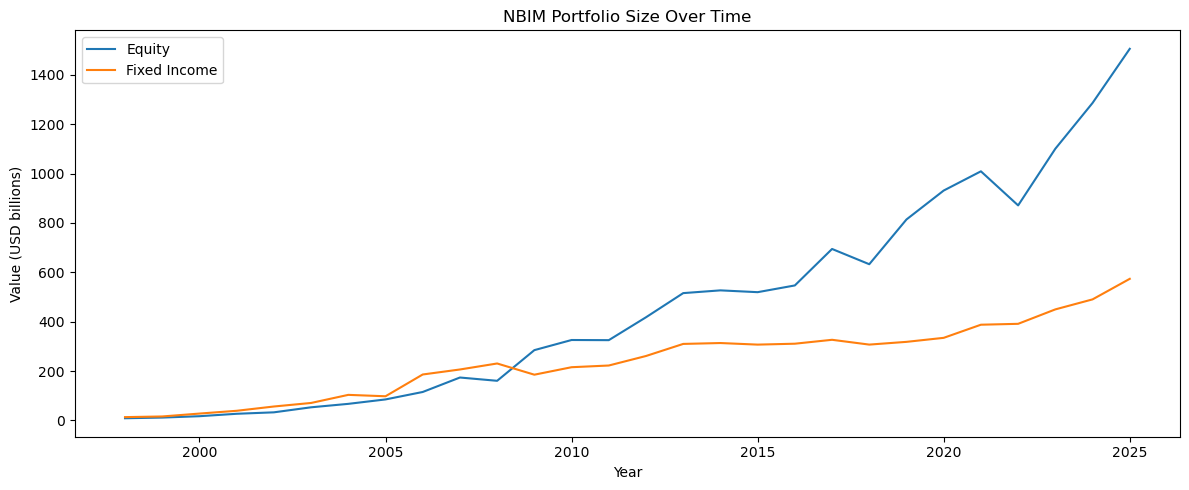

In [6]:
q = """
SELECT
    year,
    asset_class,
    SUM(value_usd) AS value_usd
FROM nbim_holdings
GROUP BY year, asset_class
ORDER BY year, asset_class
"""
df_size = pd.read_sql(q, conn)

fig, ax = plt.subplots(figsize=(12, 5))
for ac, group in df_size.groupby("asset_class"):
    ax.plot(group["year"], group["value_usd"] / 1e9, label=ac)

ax.set_title("NBIM Portfolio Size Over Time")
ax.set_ylabel("Value (USD billions)")
ax.set_xlabel("Year")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Number of Holdings Over Time
Number of distinct companies held per year, split by asset class. Reflects how the fund has diversified its portfolio as it has grown.

C:\Users\Ulf\AppData\Local\Temp\ipykernel_2076\826743523.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count = pd.read_sql(q, conn)


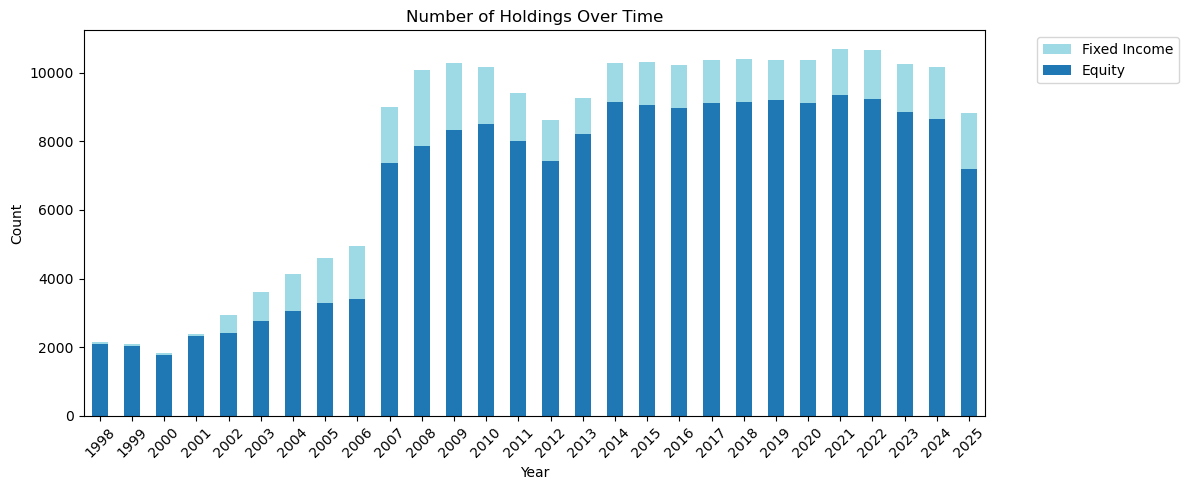

In [7]:
q = """
SELECT
    year,
    asset_class,
    COUNT(DISTINCT company) AS n_companies
FROM nbim_holdings
GROUP BY year, asset_class
ORDER BY year, asset_class
"""
df_count = pd.read_sql(q, conn)

count_wide = df_count.pivot(index="year", columns="asset_class", values="n_companies").fillna(0)
count_wide = count_wide[count_wide.iloc[-1].sort_values(ascending=False).index]

ax = count_wide.plot.bar(figsize=(12, 5), stacked=True, colormap="tab20")
plt.title("Number of Holdings Over Time")
plt.ylabel("Count")
plt.xlabel("Year")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Asset Class Allocation Over Time
Portfolio weight of Equity vs. Fixed Income per year. NBIM has gradually increased its equity allocation from ~40% in 1998 towards ~70% in recent years, in line with its mandate changes.

C:\Users\Ulf\AppData\Local\Temp\ipykernel_2076\3277605864.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn)


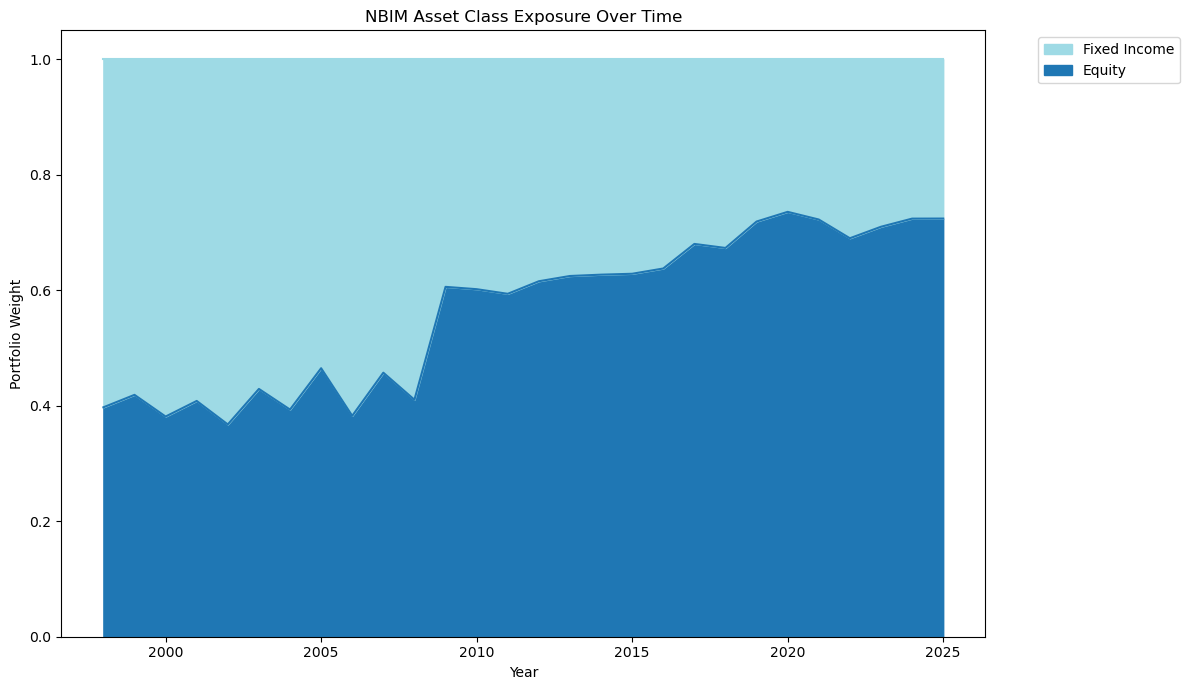

In [8]:
q = """
SELECT
    year,
    asset_class,
    SUM(value_usd) AS value_usd
FROM nbim_holdings
GROUP BY year, asset_class
ORDER BY year, asset_class
"""
df = pd.read_sql(q, conn)

df["total_year"] = df.groupby("year")["value_usd"].transform("sum")
df["weight"] = df["value_usd"] / df["total_year"]
class_wide = df.pivot(index="year", columns="asset_class", values="weight").fillna(0)
class_wide = class_wide[class_wide.iloc[-1].sort_values(ascending=False).index]

ax = class_wide.plot.area(figsize=(12, 7), colormap="tab20")
plt.title("NBIM Asset Class Exposure Over Time")
plt.ylabel("Portfolio Weight")
plt.xlabel("Year")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 5. Geographic Exposure Over Time
Equity portfolio weight per continent over time. North America has risen sharply relative to Europe over the past decade, driven primarily by the outperformance of US technology companies.

C:\Users\Ulf\AppData\Local\Temp\ipykernel_2076\4211937337.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_geo = pd.read_sql(q, conn)


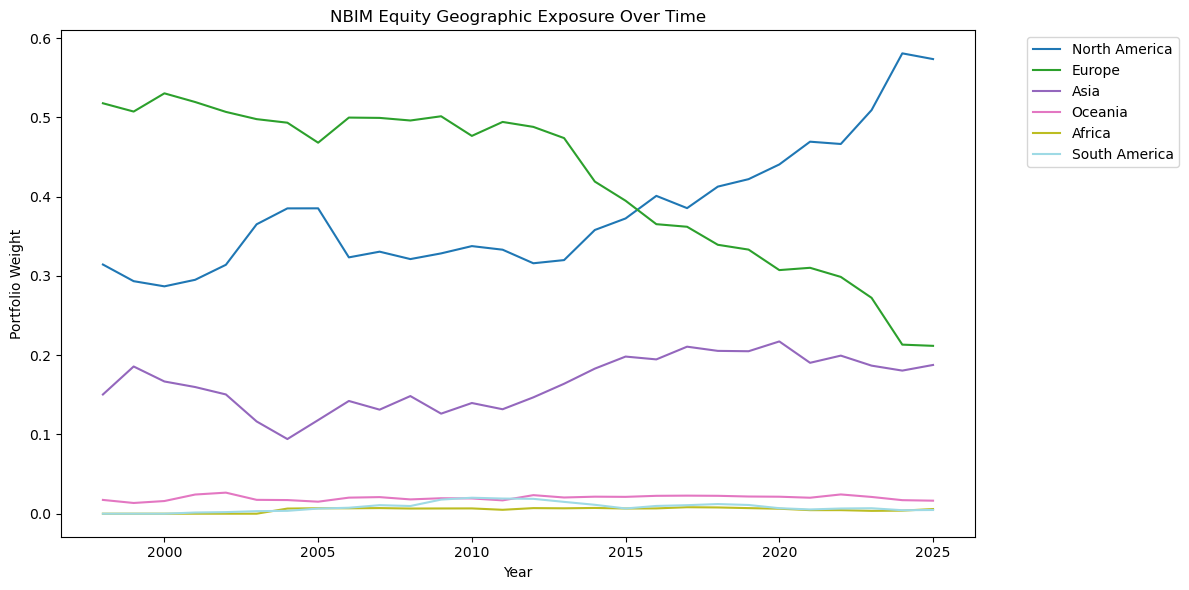

In [9]:
q = """
SELECT
    year,
    country_code,
    SUM(value_usd) AS value_usd
FROM nbim_holdings
WHERE asset_class = 'Equity'
    AND country_code IS NOT NULL
GROUP BY year, country_code
ORDER BY year, value_usd DESC
"""
df_geo = pd.read_sql(q, conn)

df_geo["continent"] = df_geo["country_code"].apply(country_to_continent)

df_cont = (
    df_geo.groupby(["year", "continent"])["value_usd"]
    .sum()
    .reset_index()
)
df_cont["total_year"] = df_cont.groupby("year")["value_usd"].transform("sum")
df_cont["weight"]     = df_cont["value_usd"] / df_cont["total_year"]

cont_wide = df_cont.pivot(index="year", columns="continent", values="weight").fillna(0)
cont_wide = cont_wide[cont_wide.iloc[-1].sort_values(ascending=False).index]
cont_wide = cont_wide.drop(columns=["Unknown"], errors="ignore")

ax = cont_wide.plot(figsize=(12, 6), colormap="tab20")
plt.title("NBIM Equity Geographic Exposure Over Time")
plt.ylabel("Portfolio Weight")
plt.xlabel("Year")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 6. Equity Sector Exposure Over Time
Portfolio weight per GICS sector within the equity portfolio. Technology has grown substantially in recent years, reflecting both active allocation shifts and passive market-cap weighting effects.

C:\Users\Ulf\AppData\Local\Temp\ipykernel_2076\918132282.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn)


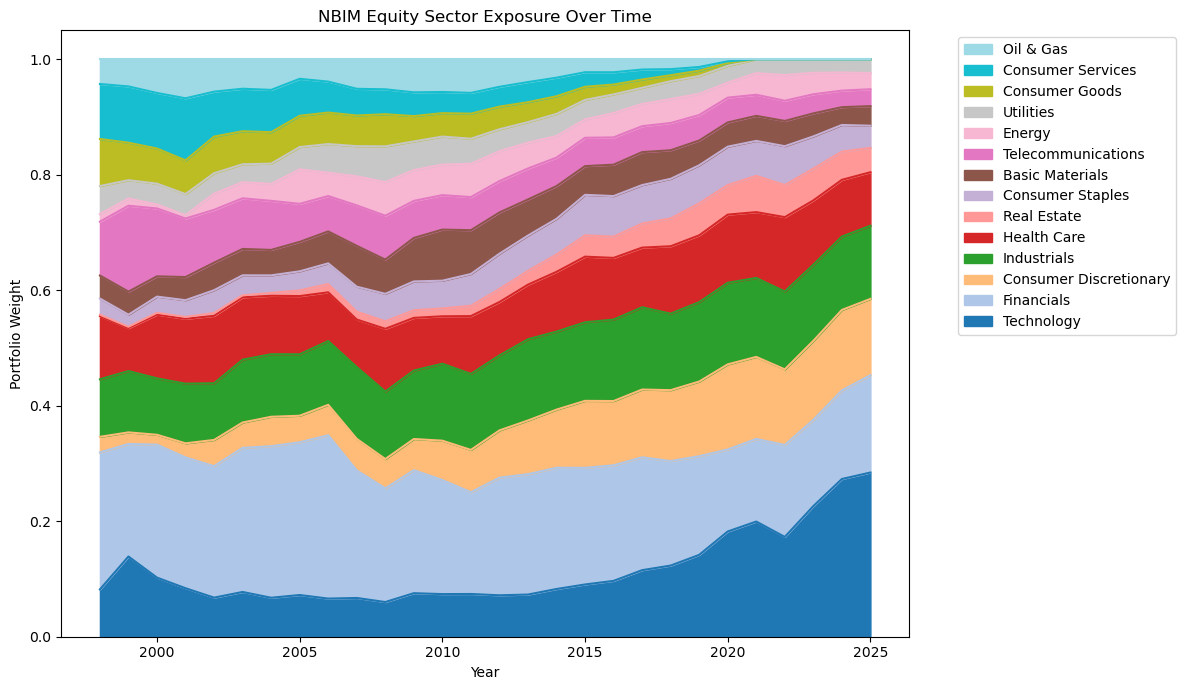

In [10]:
q = """
SELECT
    year,
    sector_std AS sector,
    SUM(value_usd) AS value_usd
FROM nbim_holdings
WHERE asset_class = 'Equity'
    AND sector_std IS NOT NULL
GROUP BY year, sector_std
ORDER BY year, sector_std
"""
df = pd.read_sql(q, conn)
df["total_year"] = df.groupby("year")["value_usd"].transform("sum")
df["weight"] = df["value_usd"] / df["total_year"]
sector_wide = df.pivot(index="year", columns="sector", values="weight").fillna(0)
sector_wide = sector_wide[sector_wide.iloc[-1].sort_values(ascending=False).index]

ax = sector_wide.plot.area(figsize=(12, 7), colormap="tab20")
plt.title("NBIM Equity Sector Exposure Over Time")
plt.ylabel("Portfolio Weight")
plt.xlabel("Year")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 7. Fixed Income Sector Exposure Over Time
Portfolio weight per bond type within the fixed income portfolio. Corporate bonds have grown as a share of the fixed income allocation, while Government bonds have declined relatively.

C:\Users\Ulf\AppData\Local\Temp\ipykernel_2076\3107876909.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn)


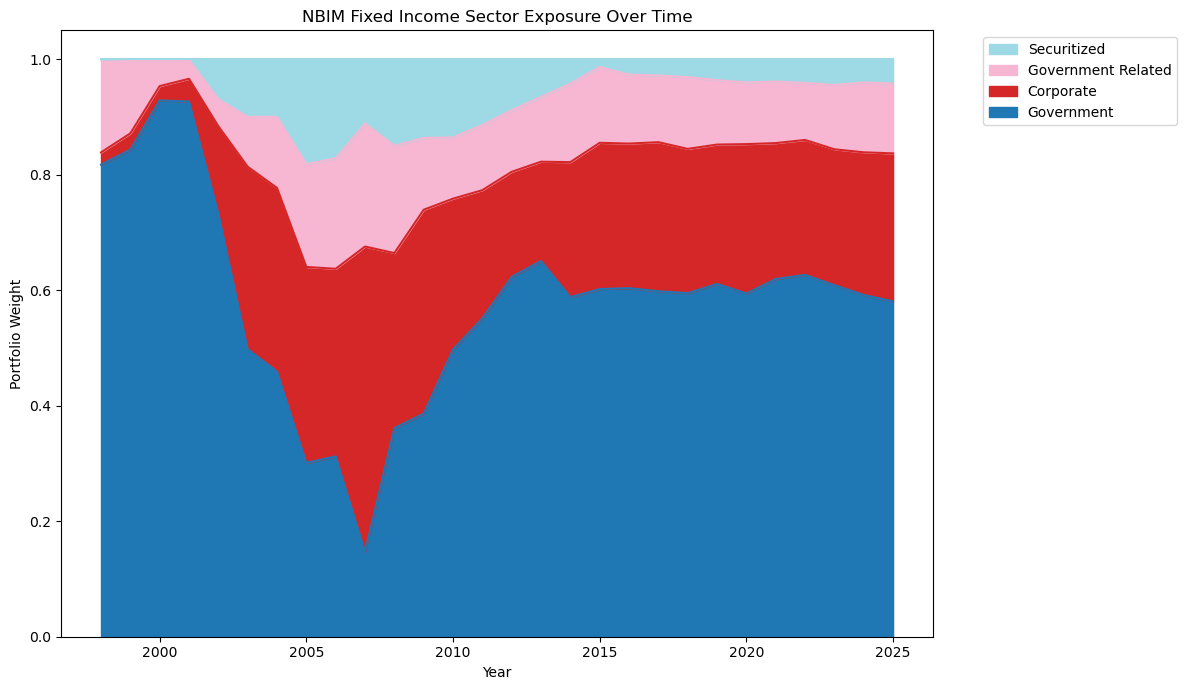

In [11]:
q = """
SELECT
    year,
    fi_sector_std AS sector,
    SUM(value_usd) AS value_usd
FROM nbim_holdings
WHERE asset_class = 'Fixed Income'
    AND fi_sector_std IS NOT NULL
GROUP BY year, fi_sector_std
ORDER BY year, fi_sector_std
"""
df = pd.read_sql(q, conn)
df["total_year"] = df.groupby("year")["value_usd"].transform("sum")
df["weight"] = df["value_usd"] / df["total_year"]
fi_wide = df.pivot(index="year", columns="sector", values="weight").fillna(0)
fi_wide = fi_wide[fi_wide.iloc[-1].sort_values(ascending=False).index]

ax = fi_wide.plot.area(figsize=(12, 7), colormap="tab20")
plt.title("NBIM Fixed Income Sector Exposure Over Time")
plt.ylabel("Portfolio Weight")
plt.xlabel("Year")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 8. Portfolio Concentration
Two complementary measures of equity concentration over time:
- **Top-10 share**: the combined weight of the 10 largest equity holdings
- **HHI (Herfindahl-Hirschman Index)**: sum of squared weights across all holdings — values near 0 indicate high diversification

Both metrics declined through 2016 as the fund expanded into new markets, before rising sharply in recent years driven by the outperformance of a small number of US technology companies (the "Magnificent 7" effect).

C:\Users\Ulf\AppData\Local\Temp\ipykernel_2076\736087060.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn)
C:\Users\Ulf\AppData\Local\Temp\ipykernel_2076\736087060.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["weight"] ** 2).sum())


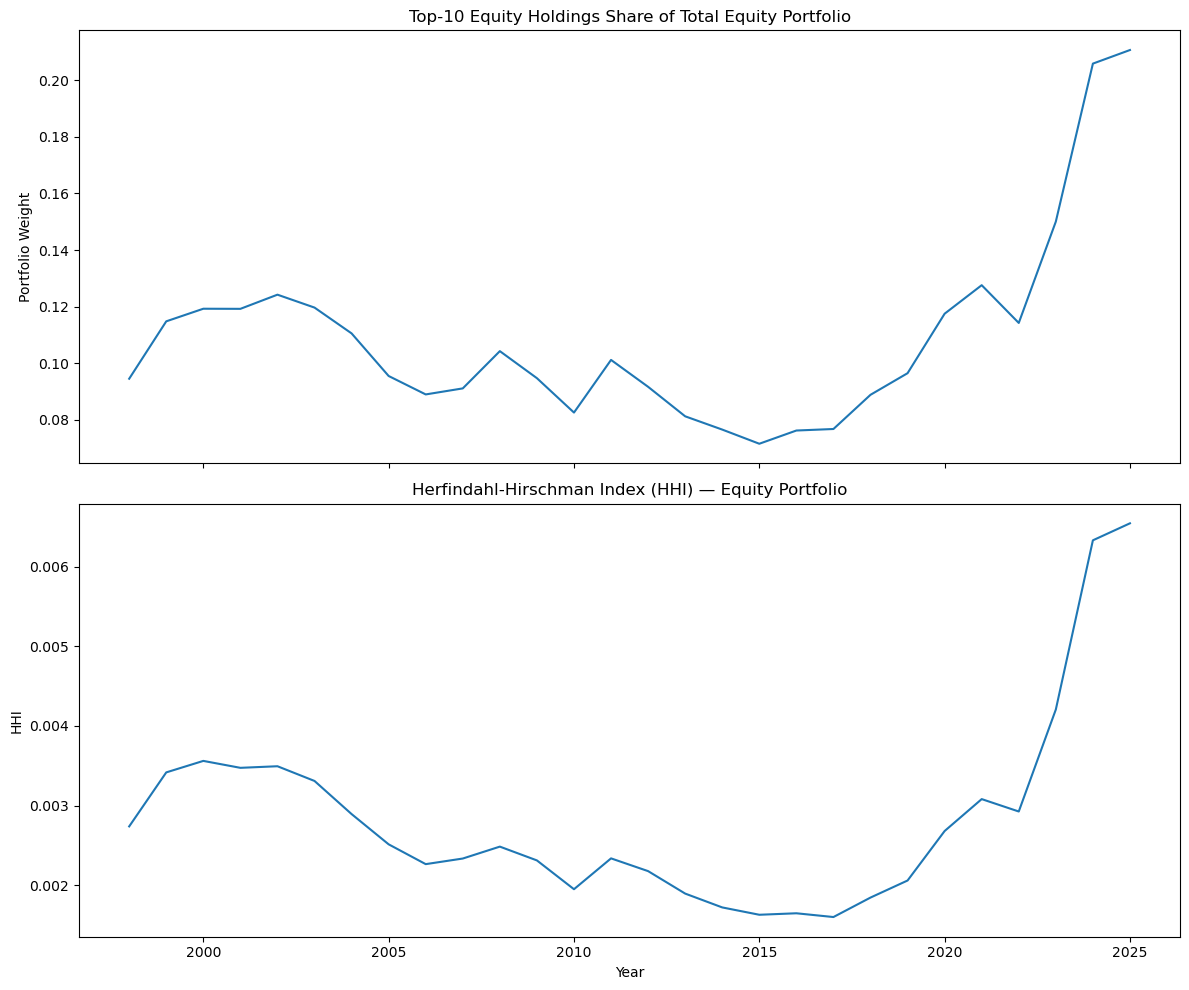

In [12]:
q = """
SELECT
    year,
    company,
    SUM(value_usd) AS value_usd
FROM nbim_holdings
WHERE asset_class = 'Equity'
GROUP BY year, company
ORDER BY year, value_usd DESC
"""
df = pd.read_sql(q, conn)

df["total_year"] = df.groupby("year")["value_usd"].transform("sum")
df["weight"]     = df["value_usd"] / df["total_year"]
df["rank"]       = df.groupby("year")["value_usd"].rank(ascending=False, method="first")

top10 = (
    df[df["rank"] <= 10]
    .groupby("year")["weight"]
    .sum()
    .reset_index(name="top10_share")
)

hhi = (
    df.groupby("year")
    .apply(lambda x: (x["weight"] ** 2).sum())
    .reset_index(name="hhi")
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(top10["year"], top10["top10_share"])
ax1.set_title("Top-10 Equity Holdings Share of Total Equity Portfolio")
ax1.set_ylabel("Portfolio Weight")

ax2.plot(hhi["year"], hhi["hhi"])
ax2.set_title("Herfindahl-Hirschman Index (HHI) — Equity Portfolio")
ax2.set_ylabel("HHI")
ax2.set_xlabel("Year")

plt.tight_layout()
plt.show()

### Top-5 Equity Holdings by Year (2020–2025)
Breakdown of the five largest equity positions per year, showing the growing dominance of US technology companies — in particular NVIDIA, which rose from outside the top-5 in 2022 to the single largest holding in 2025.

In [13]:
(
    df[df["year"] >= 2020]
    .sort_values(["year", "rank"])
    .groupby("year")
    .head(5)[["year", "company", "weight"]]
    .reset_index(drop=True)
)

,year,company,weight
0,2020,Apple Inc,0.023248
1,2020,Microsoft Corp,0.018551
2,2020,Amazon.com Inc,0.015596
3,2020,Alphabet Inc,0.012210
4,2020,Nestle SA,0.009662
5,2021,Apple Inc,0.024383
6,2021,Microsoft Corp,0.023654
7,2021,Alphabet Inc,0.016231
8,2021,Amazon.com Inc,0.013617
9,2021,Nestle SA,0.010012
